In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt



In [3]:
f = 2.4e9
c = 3e8

def free_space_path_loss(d,f):
  return 20*np.log10(d) + 20*np.log10(f) + 20*np.log10(4*np.pi/c) + np.random.normal(0,2,len(d))

num_samples = 500
distances = np.linspace(1,100,num_samples)
path_loss_dB = free_space_path_loss(distances,f)
tx_power_dB = 0
rx_power_dB = tx_power_dB - path_loss_dB
X = distances.reshape(-1,1)
y = rx_power_dB
y

array([-39.81027512, -39.89249892, -41.20207284, -45.51725263,
       -46.04409357, -47.90856981, -46.02862571, -44.06190281,
       -44.86082182, -50.86397051, -46.85967484, -51.08421469,
       -50.86007612, -50.45419775, -54.47567177, -51.52626343,
       -52.59007762, -52.48543367, -52.21131726, -54.00519255,
       -54.02795091, -54.65662091, -56.09803511, -53.82357045,
       -52.98756361, -57.36802588, -57.10050036, -57.17868457,
       -52.22444187, -57.91268548, -60.1960778 , -57.96855129,
       -55.90953548, -56.08593381, -59.07904918, -57.83422891,
       -56.18240826, -57.16196195, -59.86323362, -57.43861356,
       -58.01057998, -60.14317074, -59.07127053, -57.30321251,
       -59.81768114, -60.03313877, -60.0335021 , -58.4759432 ,
       -58.26392931, -60.28150056, -65.31192174, -62.17667651,
       -60.75311467, -64.50793541, -59.13525028, -60.48098507,
       -60.38174951, -63.12346948, -60.89485667, -59.24665564,
       -63.42506932, -60.40818336, -62.45460998, -63.15

Train-Test split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Linear Regression

In [5]:
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

rx_power_linear_pred = linear_reg.predict(X_test)

Polynomial Regression

In [6]:
degree = 4
poly_features = PolynomialFeatures(degree=degree)

X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

poly_reg_model = LinearRegression()
poly_reg_model.fit(X_train_poly, y_train)

rx_power_poly_pred = poly_reg_model.predict(X_test_poly)

MSE and R2 score

In [7]:
from sklearn.metrics import mean_squared_error, r2_score

mse_linear = mean_squared_error(y_test, rx_power_linear_pred)
r2_linear = r2_score(y_test, rx_power_linear_pred)

mse_poly = mean_squared_error(y_test, rx_power_poly_pred)
r2_poly = r2_score(y_test, rx_power_poly_pred)

print("Linear Regression:")
print("MSE:", mse_linear)
print("R2 Score:", r2_linear)

print("\nPolynomial Regression (degree = 4):")
print("MSE:", mse_poly)
print("R2 Score:", r2_poly)


Linear Regression:
MSE: 19.574146222321605
R2 Score: 0.760321778112238

Polynomial Regression (degree = 4):
MSE: 4.775947790350829
R2 Score: 0.9415202757137519


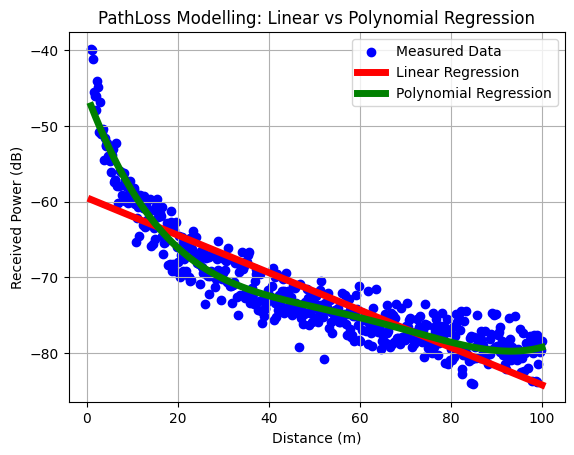

In [8]:
import matplotlib.pyplot as plt

rx_power_linear_pred_full = linear_reg.predict(X)

X_poly_full = poly_features.transform(X)
rx_power_poly_pred_full = poly_reg_model.predict(X_poly_full)

plt.scatter(distances, rx_power_dB, color='blue', label='Measured Data')
plt.plot(distances, rx_power_linear_pred_full, color='red', linewidth=5, label='Linear Regression')
plt.plot(distances, rx_power_poly_pred_full, color='green', linewidth=5, label='Polynomial Regression')
plt.xlabel('Distance (m)')
plt.ylabel('Received Power (dB)')
plt.title('PathLoss Modelling: Linear vs Polynomial Regression')
plt.legend()
plt.grid(True)
plt.show()